In [122]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 1412

# Specify each path

In [123]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.hdf5'

# Set number of classes

In [124]:
NUM_CLASSES = 24

# Dataset reading

In [125]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [126]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [127]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# Model building

In [128]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [129]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout_12 (Dropout)        (None, 42)                0         
                                                                 
 dense_18 (Dense)            (None, 20)                860       
                                                                 
 dropout_13 (Dropout)        (None, 20)                0         
                                                                 
 dense_19 (Dense)            (None, 10)                210       
                                                                 
 dense_20 (Dense)            (None, 24)                264       
                                                                 
Total params: 1,334
Trainable params: 1,334
Non-trainable params: 0
_________________________________________________________________


In [130]:
# Model Checkpoint Callbacks
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Early abort callback
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [131]:
# model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [132]:
model.fit(
    X_train,
    y_train,
    epochs=500,
    batch_size=150,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/500
 1/10 [==>...........................] - ETA: 2s - loss: 3.1992 - accuracy: 0.0200
Epoch 1: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 1s 20ms/step - loss: 3.2065 - accuracy: 0.0319 - val_loss: 3.1804 - val_accuracy: 0.0437
Epoch 2/500
 1/10 [==>...........................] - ETA: 0s - loss: 3.1995 - accuracy: 0.0600
Epoch 2: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 3.1872 - accuracy: 0.0507 - val_loss: 3.1673 - val_accuracy: 0.0812
Epoch 3/500
 1/10 [==>...........................] - ETA: 0s - loss: 3.1752 - accuracy: 0.0400
Epoch 3: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 3.1733 - accuracy: 0.0465 - val_loss: 3.1541 - val_accuracy: 0.0771
Epoch 4/500
 1/10 [==>...........................] - ETA: 0s - loss: 3.1644 - accuracy: 0.0733
Epoc

 1/10 [==>...........................] - ETA: 0s - loss: 2.1448 - accuracy: 0.2933
Epoch 55: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 2.1625 - accuracy: 0.2965 - val_loss: 1.7835 - val_accuracy: 0.5104
Epoch 56/500
 1/10 [==>...........................] - ETA: 0s - loss: 2.1085 - accuracy: 0.3333
Epoch 56: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 2.1429 - accuracy: 0.2993 - val_loss: 1.7630 - val_accuracy: 0.5437
Epoch 57/500
 1/10 [==>...........................] - ETA: 0s - loss: 2.1153 - accuracy: 0.2800
Epoch 57: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 2.1190 - accuracy: 0.2854 - val_loss: 1.7414 - val_accuracy: 0.5583
Epoch 58/500
 1/10 [==>...........................] - ETA: 0s - loss: 2.1383 - accuracy: 0.3000
Epoch 58: s

 1/10 [==>...........................] - ETA: 0s - loss: 1.8587 - accuracy: 0.3867
Epoch 109: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 1.8119 - accuracy: 0.3743 - val_loss: 1.2235 - val_accuracy: 0.8042
Epoch 110/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.8056 - accuracy: 0.3667
Epoch 110: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 1.7961 - accuracy: 0.3743 - val_loss: 1.2160 - val_accuracy: 0.7937
Epoch 111/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.8548 - accuracy: 0.3200
Epoch 111: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 1.8374 - accuracy: 0.3653 - val_loss: 1.2143 - val_accuracy: 0.8167
Epoch 112/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.8279 - accuracy: 0.3933
Epoch

Epoch 136/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.7085 - accuracy: 0.4467
Epoch 136: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 1.7373 - accuracy: 0.3938 - val_loss: 1.1037 - val_accuracy: 0.8167
Epoch 137/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.7267 - accuracy: 0.4333
Epoch 137: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 5ms/step - loss: 1.7074 - accuracy: 0.4160 - val_loss: 1.1023 - val_accuracy: 0.8396
Epoch 138/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.7026 - accuracy: 0.4533
Epoch 138: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 1.6930 - accuracy: 0.4139 - val_loss: 1.0964 - val_accuracy: 0.8562
Epoch 139/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.9448 - accuracy

Epoch 163/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.6542 - accuracy: 0.4467
Epoch 163: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 10ms/step - loss: 1.6764 - accuracy: 0.4069 - val_loss: 1.0225 - val_accuracy: 0.8562
Epoch 164/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.6027 - accuracy: 0.4600
Epoch 164: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 7ms/step - loss: 1.6060 - accuracy: 0.4368 - val_loss: 1.0138 - val_accuracy: 0.8583
Epoch 165/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.5795 - accuracy: 0.4267
Epoch 165: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 1.6200 - accuracy: 0.4306 - val_loss: 1.0106 - val_accuracy: 0.8938
Epoch 166/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.5377 - accurac

...

Epoch 271/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.5033 - accuracy: 0.5133
Epoch 271: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 1.4762 - accuracy: 0.4771 - val_loss: 0.7857 - val_accuracy: 0.9271
Epoch 272/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.4412 - accuracy: 0.4867
Epoch 272: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 1.4578 - accuracy: 0.5028 - val_loss: 0.7843 - val_accuracy: 0.9312
Epoch 273/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.4224 - accuracy: 0.4267
Epoch 273: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 1.4988 - accuracy: 0.4819 - val_loss: 0.7857 - val_accuracy: 0.9250
Epoch 274/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.5497 - accuracy

Epoch 298/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.4106 - accuracy: 0.4800
Epoch 298: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 5ms/step - loss: 1.4445 - accuracy: 0.4799 - val_loss: 0.7509 - val_accuracy: 0.9146
Epoch 299/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.3050 - accuracy: 0.5200
Epoch 299: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 1.4478 - accuracy: 0.4889 - val_loss: 0.7483 - val_accuracy: 0.9062
Epoch 300/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.4537 - accuracy: 0.5200
Epoch 300: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 1.4460 - accuracy: 0.5042 - val_loss: 0.7433 - val_accuracy: 0.9271
Epoch 301/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.5073 - accuracy

Epoch 325/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.4479 - accuracy: 0.4800
Epoch 325: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 1.3614 - accuracy: 0.5271 - val_loss: 0.7165 - val_accuracy: 0.9271
Epoch 326/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.4554 - accuracy: 0.4600
Epoch 326: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 1.3948 - accuracy: 0.5049 - val_loss: 0.7142 - val_accuracy: 0.9271
Epoch 327/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.3132 - accuracy: 0.5400
Epoch 327: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 1.4661 - accuracy: 0.4812 - val_loss: 0.7144 - val_accuracy: 0.9354
Epoch 328/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.5334 - accuracy

Epoch 352/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.3511 - accuracy: 0.5067
Epoch 352: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 1.3874 - accuracy: 0.5090 - val_loss: 0.7013 - val_accuracy: 0.9208
Epoch 353/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.3595 - accuracy: 0.5000
Epoch 353: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 1.4154 - accuracy: 0.5007 - val_loss: 0.7028 - val_accuracy: 0.9354
Epoch 354/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.3868 - accuracy: 0.5200
Epoch 354: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 1.4039 - accuracy: 0.4993 - val_loss: 0.7027 - val_accuracy: 0.9354
Epoch 355/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.3820 - accuracy

Epoch 379/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.3906 - accuracy: 0.4933
Epoch 379: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 1.3870 - accuracy: 0.5042 - val_loss: 0.6848 - val_accuracy: 0.9229
Epoch 380/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.3862 - accuracy: 0.5400
Epoch 380: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 9ms/step - loss: 1.3923 - accuracy: 0.5139 - val_loss: 0.6883 - val_accuracy: 0.9187
Epoch 381/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.3521 - accuracy: 0.4733
Epoch 381: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
10/10 [==============================] - 0s 6ms/step - loss: 1.4133 - accuracy: 0.5118 - val_loss: 0.6890 - val_accuracy: 0.9250
Epoch 382/500
 1/10 [==>...........................] - ETA: 0s - loss: 1.4063 - accuracy

In [133]:
# model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

4/4 [==============================] - 0s 1ms/step - loss: 0.6824 - accuracy: 0.9396


In [134]:
# Loading a saved model
model = tf.keras.models.load_model(model_save_path)

In [135]:
# Reasoning test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 [==============================] - 0s 36ms/step
[2.5561376e-04 2.9265473e-02 4.6751732e-03 2.3277022e-02 4.7614668e-03
 2.9244325e-03 1.8480417e-03 4.5375214e-03 4.3649234e-05 1.0473194e-01
 1.1456753e-03 2.8690122e-04 6.7477849e-05 2.6637102e-03 9.1926349e-06
 1.3623037e-06 6.0583055e-02 6.6641450e-04 1.0285768e-04 1.8191494e-01
 4.5496804e-01 1.0796171e-01 1.3267605e-02 4.0668143e-05]
20


# Confusion matrix

15/15 [==============================] - 0s 755us/step


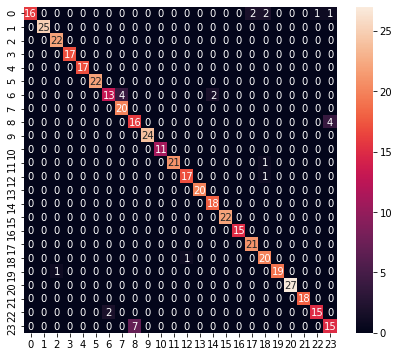

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.73      0.84        22
           1       1.00      1.00      1.00        25
           2       0.96      1.00      0.98        22
           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        17
           5       1.00      1.00      1.00        22
           6       0.87      0.68      0.76        19
           7       0.83      1.00      0.91        20
           8       0.70      0.80      0.74        20
           9       1.00      1.00      1.00        24
          10       1.00      1.00      1.00        11
          11       1.00      0.95      0.98        22
          12       0.94      0.94      0.94        18
          13       1.00      1.00      1.00        20
          14       0.90      1.00      0.95        18
          15       1.00      1.00      1.00        22
          16       1.00      1.00      1.00        15
     

In [136]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [137]:
# Save as an inference-only model
model.save(model_save_path, include_optimizer=False)

In [138]:
# Transform (quantize) the model
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\Phipr\AppData\Local\Temp\tmp6qlz8cza\assets


INFO:tensorflow:Assets written to: C:\Users\Phipr\AppData\Local\Temp\tmp6qlz8cza\assets


7488

# Inference test

In [139]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [140]:
# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [141]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [142]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

Wall time: 0 ns


In [143]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[2.5561376e-04 2.9265476e-02 4.6751741e-03 2.3277035e-02 4.7614682e-03
 2.9244339e-03 1.8480428e-03 4.5375223e-03 4.3649321e-05 1.0473191e-01
 1.1456754e-03 2.8690140e-04 6.7477849e-05 2.6637123e-03 9.1926368e-06
 1.3623064e-06 6.0583040e-02 6.6641398e-04 1.0285769e-04 1.8191493e-01
 4.5496809e-01 1.0796176e-01 1.3267603e-02 4.0668187e-05]
20
